In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df['bmi']=df['bmi'].fillna(df['bmi']).mean()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,28.893237,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,28.893237,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,28.893237,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,28.893237,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,28.893237,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,28.893237,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,28.893237,formerly smoked,0


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])

In [ ]:
x=df.iloc[:,:-1]

In [ ]:
y=df['stroke']


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
xtrain = pd.DataFrame(x_train)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:

ss=StandardScaler()
for i in xtrain.columns:
  if xtrain[i].dtypes != 'object':
    xtrain[i]=ss.fit_transform(xtrain[[i]])


In [ ]:
xtrain

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
802,-1.489746,1.192995,1.584155,-0.321981,-0.236189,0.726005,0.771792,-1.023265,0.135593,7.105427e-15,-0.352725
3927,0.937247,-0.838227,0.829708,-0.321981,-0.236189,0.726005,-0.142991,0.977264,-0.397457,7.105427e-15,-1.285415
2337,0.863868,-0.838227,-0.989841,-0.321981,-0.236189,-1.377402,-0.142991,-1.023265,-1.028701,7.105427e-15,0.579965
3910,0.008086,1.192995,-0.546049,-0.321981,-0.236189,0.726005,-1.972556,0.977264,-0.893246,7.105427e-15,-0.352725
1886,1.176023,-0.838227,-0.546049,-0.321981,-0.236189,-1.377402,-0.142991,-1.023265,-1.026290,7.105427e-15,0.579965
...,...,...,...,...,...,...,...,...,...,...,...
4426,-1.068732,1.192995,-0.013498,-0.321981,-0.236189,0.726005,-1.972556,-1.023265,-0.404471,7.105427e-15,0.579965
466,-1.663492,-0.838227,0.785328,3.105774,-0.236189,0.726005,-0.142991,-1.023265,1.393916,7.105427e-15,1.512655
3092,-0.232256,-0.838227,-1.870325,-0.321981,-0.236189,-1.377402,1.686575,0.977264,-0.201070,7.105427e-15,-1.285415
3772,1.207139,1.192995,1.628534,-0.321981,-0.236189,0.726005,0.771792,-1.023265,1.964446,7.105427e-15,-0.352725


In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow import keras

In [ ]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(11,)),
    keras.layers.Dense(20,activation='relu'),
    keras.layers.Dense(2,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

In [ ]:
history= model.fit(xtrain,y_train,validation_split=0.1,epochs=25)

Epoch 1/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7782 - loss: 0.4886 - val_accuracy: 0.9511 - val_loss: 0.2853
Epoch 2/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9543 - loss: 0.2245 - val_accuracy: 0.9487 - val_loss: 0.2012
Epoch 3/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9546 - loss: 0.1857 - val_accuracy: 0.9487 - val_loss: 0.1801
Epoch 4/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9546 - loss: 0.1735 - val_accuracy: 0.9487 - val_loss: 0.1706
Epoch 5/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9546 - loss: 0.1672 - val_accuracy: 0.9487 - val_loss: 0.1655
Epoch 6/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9543 - loss: 0.1628 - val_accuracy: 0.9487 - val_loss: 0.1627
Epoch 7/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9546 - loss: 0.1596 - val_accuracy: 0.9487 - val_loss: 0.1597
Epoch 8/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9546 - loss: 0.1574 - val_accuracy: 0.

/tmp/ipykernel_1791/4133400113.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('training data','accuracy')


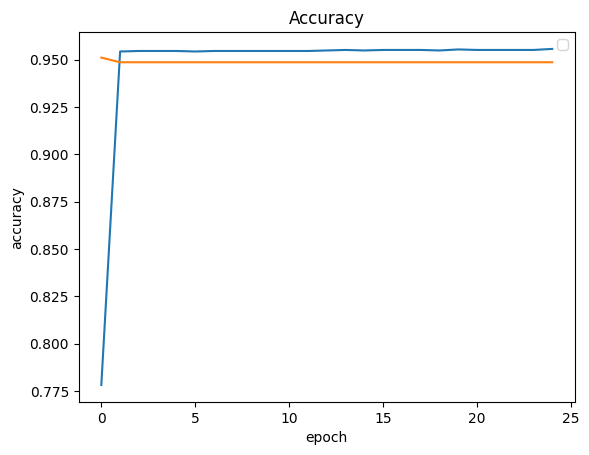

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend('training data','accuracy')

Text(0, 0.5, 'accuracy')

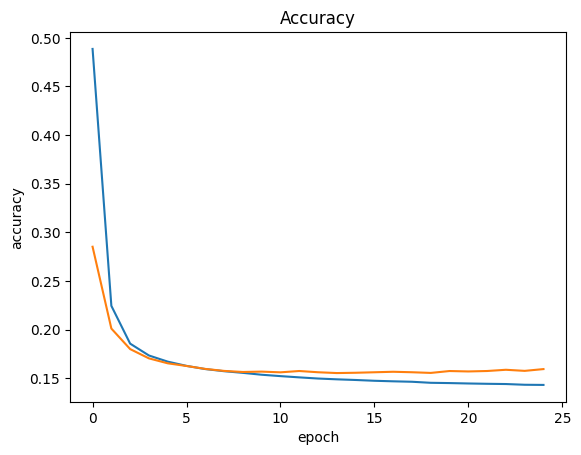

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')